In [ ]:
import sys
sys.path.append('..')

from Agent.config import LLM, SMALL_LLM, SMART_LLM, EMBEDDING, CLIENT
from IPython.display import display, Image, Markdown

# 3.7 "찐" Multi-Agent System (feat. create_react_agent)

- 도구들을 활용하는 에이전트들이 협업하는 과정을 구현합니다

In [2]:
from langchain_openai import AzureChatOpenAI

llm = LLM

small_llm = SMALL_LLM

In [3]:
%pip install --upgrade --quiet  yfinance


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
from langgraph.graph import MessagesState
from langgraph.types import Command
from typing import Literal
from langchain_core.messages import HumanMessage
from langchain_community.tools.yahoo_finance_news import YahooFinanceNewsTool

from langgraph.prebuilt import create_react_agent
from langchain_community.agent_toolkits.polygon.toolkit import PolygonToolkit
from langchain_community.utilities.polygon import PolygonAPIWrapper

# 시장 조사 도구 목록을 생성합니다.
market_research_tools = [YahooFinanceNewsTool()]

# 시장 조사 에이전트를 생성합니다.
market_research_agent = create_react_agent(
    llm, 
    tools=market_research_tools, 
    state_modifier='You are a market researcher. Provide fact only not opinions'
)

def market_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    """
    시장 조사 node입니다. 주어진 state를 기반으로 시장 조사 에이전트를 호출하고,
    결과를 supervisor node로 전달합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: supervisor node로 이동하기 위한 명령을 반환합니다.
    """
    # 시장 조사 에이전트를 호출하여 결과를 얻습니다.
    result = market_research_agent.invoke(state)
    
    # 결과 메시지를 업데이트하고 supervisor node로 이동합니다.
    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='market_research')]},
        goto='supervisor'
    )

In [5]:
import yfinance as yf

from langchain.tools import tool

@tool
def get_stock_price(ticker: str) -> dict:
    """Given a stock ticker, return the price data for the past month"""
    stock_info = yf.download(ticker, period='1mo').to_dict()
    return stock_info


stock_research_tools = [get_stock_price]
stock_research_agent = create_react_agent(
    llm, tools=stock_research_tools, state_modifier='You are a stock researcher. Provide facts only not opinions'
)

def stock_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    """
    주식 조사 node입니다. 주어진 State를 기반으로 주식 조사 에이전트를 호출하고,
    결과를 supervisor node로 전달합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: supervisor node로 이동하기 위한 명령을 반환합니다.
    """
    result = stock_research_agent.invoke(state)

    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='stock_research')]},
        goto='supervisor'
    )

In [6]:
@tool
def company_research_tool(ticker: str) -> dict:
    """Given a ticker, return the financial information and SEC filings"""
    company_info = yf.Ticker(ticker)
    financial_info = company_info.get_financials()
    sec_filings = company_info.get_sec_filings()
    return {
        'financial_info': financial_info,
        'sec_filings': sec_filings
    }

company_research_tools = [company_research_tool]
company_research_agent = create_react_agent(
    llm, tools=company_research_tools, state_modifier='You are a company researcher. Provide facts only not opinions'
)

def company_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    """
    회사 조사 node입니다. 주어진 State를 기반으로 회사 조사 에이전트를 호출하고,
    결과를 supervisor node로 전달합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: supervisor node로 이동하기 위한 명령을 반환합니다.
    """
    result = company_research_agent.invoke(state)

    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='company_research')]},
        goto='supervisor'
    )

In [7]:
from langchain_core.prompts import PromptTemplate

analyst_prompt = PromptTemplate.from_template(
    """You are a stock market analyst. Given the following information, 
Please decide wheter to buy, sell, or hold the stock.

Information:
{messages}"""
)

analyst_chain = analyst_prompt | llm

def analyst_node(state: MessagesState):
    """
    분석가 node입니다. 주어진 State를 기반으로 분석가 체인을 호출하고,
    결과 메시지를 반환합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        dict: 분석 결과 메시지를 포함하는 딕셔너리를 반환합니다.
    """
    result = analyst_chain.invoke({'messages': state['messages'][1:]})

    return {'messages': [result]}

- `supervisor`가 회사의 매니저와 유사한 역할을 하면서, 각 에이전트들의 결과를 종합하여 작업이 끝났는지 판단합니다

In [ ]:
from typing import Literal
from typing_extensions import TypedDict

from langgraph.graph import MessagesState, END
from langgraph.types import Command


members = ["market_research", "stock_research", "company_research"]
options = members + ["FINISH"]

system_prompt = (
    "You are a supervisor managing a stock analysis team with the following workers: "
    f"{members}. "
    "Given a user request about stock investment analysis, "
    "determine which worker should act next.\n\n"
    "GUIDELINES:\n"
    "1. Check the conversation history. Messages with name='market_research', "
    "'stock_research', or 'company_research' mean that worker has already reported.\n"
    "2. You MAY re-call a worker ONLY if its previous result was clearly insufficient "
    "or if new information from another worker requires follow-up.\n"
    "3. Do NOT re-call a worker just to confirm or repeat what it already reported.\n"
    "4. When you have enough information for a final analysis, respond with 'FINISH'.\n"
    "5. You do not need ALL workers to finish — if the question can be answered "
    "with partial information, respond with 'FINISH' early.\n\n"
    "RECOMMENDED ORDER (but adapt based on the question):\n"
    "market_research → stock_research → company_research → FINISH"
)


class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""

    next: Literal[*options]



def supervisor_node(state: MessagesState) -> Command[Literal[*members, "analyst"]]:
    """
    supervisor node입니다. 주어진 State를 기반으로 각 worker의 결과를 종합하고,
    다음에 수행할 worker를 결정합니다. 모든 작업이 완료되면 analyst node로 이동합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: 다음에 수행할 worker 또는 analyst node로 이동하기 위한 명령을 반환합니다.
    """
    messages = [{'role': 'system', 'content': system_prompt}] + state['messages']
    
    # 안전장치: 이미 보고한 worker 추적 (성공이든 실패든 "보고한 것"으로 처리)
    reported = {msg.name for msg in state['messages'] if hasattr(msg, 'name') and msg.name in members}
    
    if reported >= set(members):
        return Command(goto='analyst')
    
    response = small_llm.with_structured_output(Router).invoke(messages)
    goto = response['next']
    
    if goto == 'FINISH' or goto in reported:
        goto = 'analyst'
    
    return Command(goto=goto)

- `node`를 추가하고 `edge`로 연결합니다

In [18]:
from langgraph.graph import StateGraph, START

graph_builder = StateGraph(MessagesState)

graph_builder.add_node("supervisor", supervisor_node)
graph_builder.add_node("market_research", market_research_node)
graph_builder.add_node("stock_research", stock_research_node)
graph_builder.add_node("company_research", company_research_node)
graph_builder.add_node("analyst", analyst_node)

In [19]:
graph_builder.add_edge(START, "supervisor")
graph_builder.add_edge("analyst", END)
graph = graph_builder.compile()


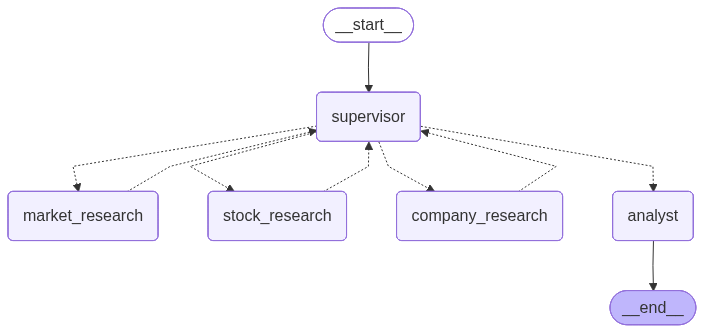

In [20]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [22]:
for chunk in graph.stream(
    {"messages": [("user", "Would you invest in OXY?")]}, stream_mode="values"
):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

Would you invest in OXY?


429 Client Error: Too Many Requests for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/OXY?modules=financialData%2CquoteType%2CdefaultKeyStatistics%2CassetProfile%2CsummaryDetail&corsDomain=finance.yahoo.com&formatted=false&symbol=OXY&crumb=Edge%3A+Too+Many+Requests


KeyboardInterrupt: 